In [1]:
# modules
import numpy as np
import matplotlib.pyplot as plt
import h5py
from datetime import datetime, timedelta
from scipy.signal import welch

In [2]:
filename = "/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250730/Y1_RDS-LES_YAW_MON_OUT_DQ_1437766016_1437852416.hdf5"

In [3]:
# Open the HDF5 file and print its structure
with h5py.File(filename, "r") as f:
    def print_hdf5_structure(name, obj):
        print(name)

    f.visititems(print_hdf5_structure)

data
timestamps


### For hdf5 files created from nds2 fetch function

In [4]:
with h5py.File(filename, "r") as f:
    data = f["data"][:] # raw samples
    print('len(data):', len(data))
    timestamps = f["timestamps"][:] # GPS‐based times
    print('len(timestamps):', len(timestamps))

len(data): 88473600
len(timestamps): 88473600


In [5]:
# convert GPS times to UTC datetime objects
gps_epoch = datetime(1980, 1, 6)
times_utc = [gps_epoch + timedelta(seconds=ts) for ts in timestamps]
print('len(times_utc):', len(times_utc))

len(times_utc): 88473600


In [12]:
from datetime import datetime, timezone
GPS_UNIX_OFFSET = 315964800
times_utc = [ datetime.fromtimestamp(t + GPS_UNIX_OFFSET, tz=timezone.utc) 
              for t in timestamps ]


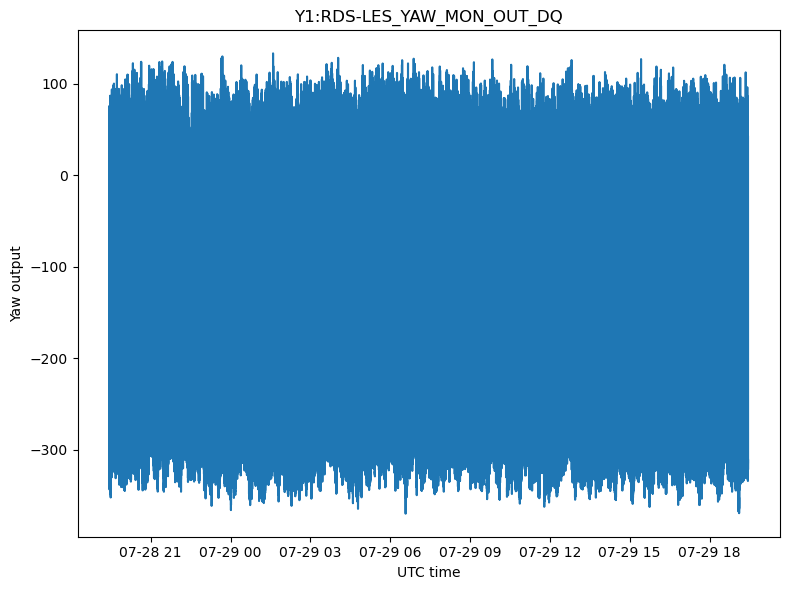

In [7]:
# downsampling to reduce plot size
max_points = int(1e5)
step = max(1, len(data) // max_points)
tsampled_data = data[::step]
tsampled_times = times_utc[::step]

plt.figure(figsize=(8, 6))
plt.plot(tsampled_times, tsampled_data)
plt.xlabel("UTC time")
plt.ylabel("Yaw output")
plt.title("Y1:RDS-LES_YAW_MON_OUT_DQ")
plt.tight_layout()

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(times_utc, data)
plt.xlabel("UTC time")
plt.ylabel("Yaw output")
plt.title("Y1:RDS-LES_YAW_MON_OUT_DQ")
plt.tight_layout()
plt.show()

### For hdf5 files created from ndscope GUI

In [6]:
# Open the HDF5 file and explore its structure
with h5py.File(filename, "r") as f:
    # List all top-level keys
    for key in f.keys():
        print("Top-level key:", key)

    # Try accessing time-series for one channel
    group = f['Y1:RDS-LES_PIT_MON_OUT_DQ']
    print("Subkeys in group:", list(group.keys()))

    # Check if there's a dataset like 'value' or 'data':
    if 'value' in group:
        values = group['value'][:]
        times = group['time'][:] if 'time' in group else range(len(values))

        plt.plot(times, values)
        plt.xlabel("Time")
        plt.ylabel("PIT Monitor Output")
        plt.title("Y1:RDS-LES_PIT_MON_OUT_DQ")
        plt.show()

Top-level key: data
Top-level key: timestamps


KeyError: "Unable to synchronously open object (object 'Y1:RDS-LES_PIT_MON_OUT_DQ' doesn't exist)"

In [ ]:
with h5py.File(filename, "r") as f:
    group = f["Y1:RDS-LES_YAW_MON_OUT_DQ"]

    # List datasets or subgroups (max/mean/min)
    print("Keys in group:", list(group.keys()))

    # Is there a time dataset?
    if 'time' in group:
        print("Found time dataset")
    else:
        print("No time dataset found in group")

    # Check for attributes that might include time info
    print("Attributes in group:")
    for key, val in group.attrs.items():
        try:
            print(f"  {key}: {val} (length: {len(val)})")
        except TypeError:
            print(f"  {key}: {val} (scalar)")

    print("Dataset lengths:")
    for key in group.keys():
        dset = group[key]
        print(f"  {key}: length = {len(dset)}")

Keys in group: ['max', 'mean', 'min']
No time dataset found in group
Attributes in group:
  gps_start: 1437933626.0 (scalar)
  sample_rate: 1.0 (scalar)
  unit: undef (length: 5)
Dataset lengths:
  max: length = 6178
  mean: length = 6178
  min: length = 6178


In [49]:
# Print out arrays of the HDF5 file
with h5py.File(filename, "r") as f:
    for channel in f.keys():
        print(f"Channel: {channel}")
        for stat in f[channel].keys():
            value = f[channel][stat][()]
            print(f"  {stat}: {value}")

Channel: Y1:RDS-LES_PIT_MON_OUT_DQ
  max: [1307.5461 1305.189  1307.5901 ... 1285.1171 1286.1821 1289.2893]
  mean: [1268.85992801 1260.97233427 1265.7868135  ... 1237.64676404 1249.5353663
 1241.22475386]
  min: [1096.3954 1095.9692 1093.4061 ... 1074.267  1077.8939 1075.8872]
Channel: Y1:RDS-LES_YAW_MON_OUT_DQ
  max: [ 77.45194   82.686905  82.890854 ... 104.52109  110.29568  105.40498 ]
  mean: [-279.27052411 -265.41098268 -268.46944672 ... -235.43653797 -248.75060261
 -236.89464712]
  min: [-341.26227 -336.53668 -327.62125 ... -309.35223 -310.03217 -310.60504]


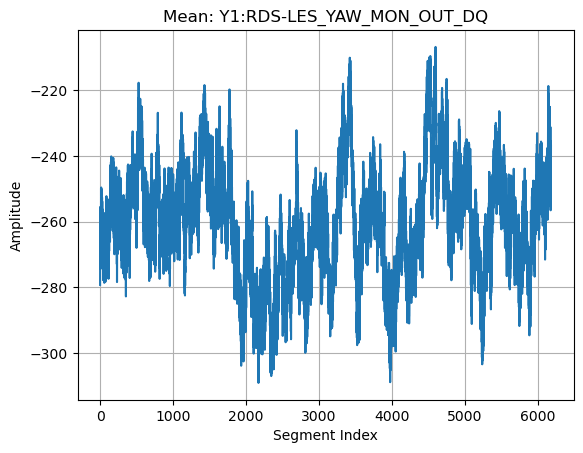

In [ ]:
# plot the mean
with h5py.File(filename, "r") as f:
    mean_pit = f["Y1:RDS-LES_YAW_MON_OUT_DQ/mean"][:]
    plt.plot(mean_pit)
    plt.title("Mean: Y1:RDS-LES_YAW_MON_OUT_DQ")
    plt.ylabel("Amplitude")
    plt.xlabel("Segment Index")
    plt.grid()
    plt.show()

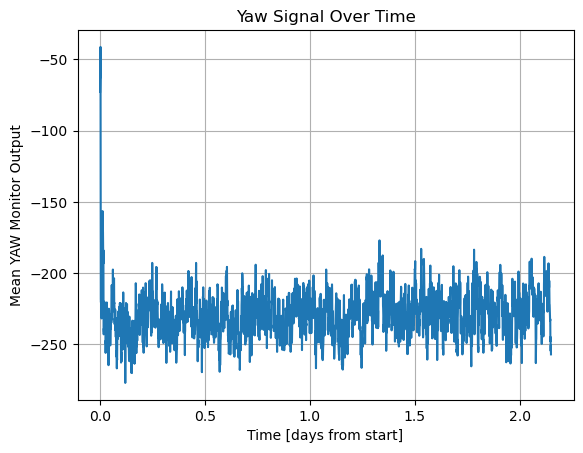

In [ ]:
with h5py.File(filename, "r") as f:
    group = f["Y1:RDS-LES_YAW_MON_OUT_DQ"]
    mean_yaw = group["mean"][:]
    sample_rate = group.attrs["sample_rate"]
    gps_start = group.attrs["gps_start"]

    # Remove NaN values
    valid_idx = ~np.isnan(mean_yaw)
    mean_yaw = mean_yaw[valid_idx]

    # Reconstruct time array
    dt = 1.0 / sample_rate  # seconds per sample (60.0)
    time_gps = np.arange(len(mean_yaw)) * dt + gps_start
    time_days = (time_gps - gps_start) / (60 * 60 * 24)  # time in days from start

plt.plot(time_days, mean_yaw)
plt.xlabel("Time [days from start]")
plt.ylabel("Mean YAW Monitor Output")
plt.title("Yaw Signal Over Time")
plt.grid()
plt.show()

In [24]:
# GPS epoch is 1980-01-06
gps_epoch = datetime(1980, 1, 6)

# Reconstruct datetime array
time_dt = [gps_epoch + timedelta(seconds=t) for t in time_gps]

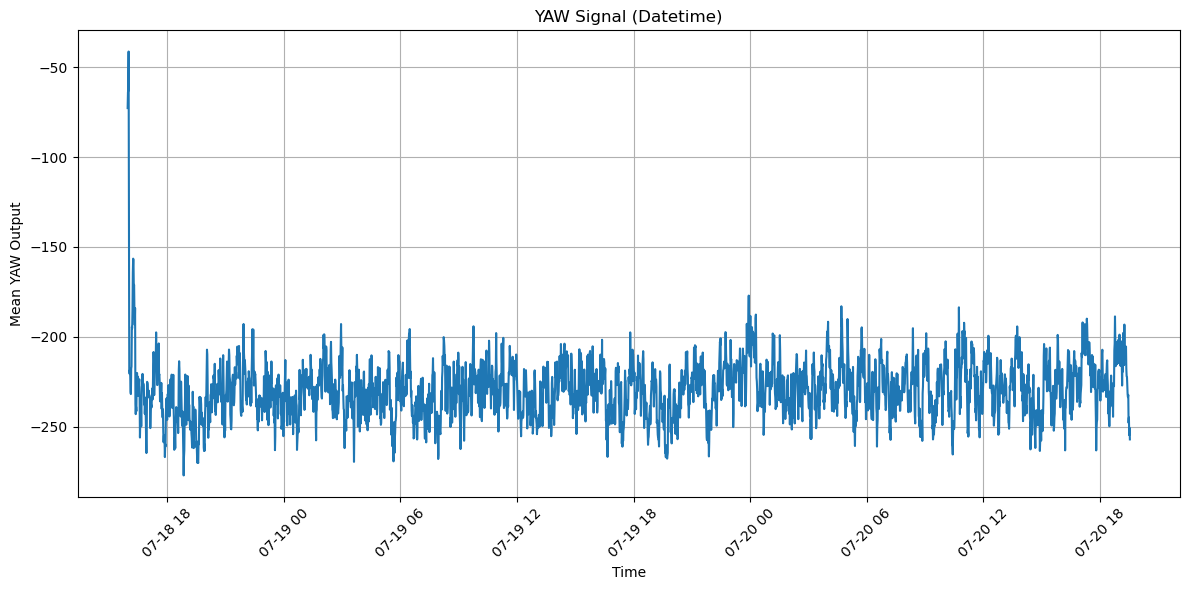

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(time_dt, mean_yaw)
plt.xlabel("Time")
plt.ylabel("Mean YAW Output")
plt.title("YAW Signal (Datetime)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

In [ ]:
fs = 1 / 60.0  # Hz (1 sample per 60 seconds -- this will change based on data extraction)
window_size = 180  # samples = 3 hours
overlap = 90       # samples = 50% overlap

dominant_freqs = []
time_stamps = []

for i in range(0, len(mean_yaw) - window_size + 1, window_size - overlap):
    chunk = mean_yaw[i:i + window_size]
    t_center = time_dt[i + window_size // 2]

    if np.isnan(chunk).any():
        continue

    f, Pxx = welch(chunk, fs=fs, nperseg=window_size)
    peak_freq = f[np.argmax(Pxx)]
    dominant_freqs.append(peak_freq)
    time_stamps.append(t_center)

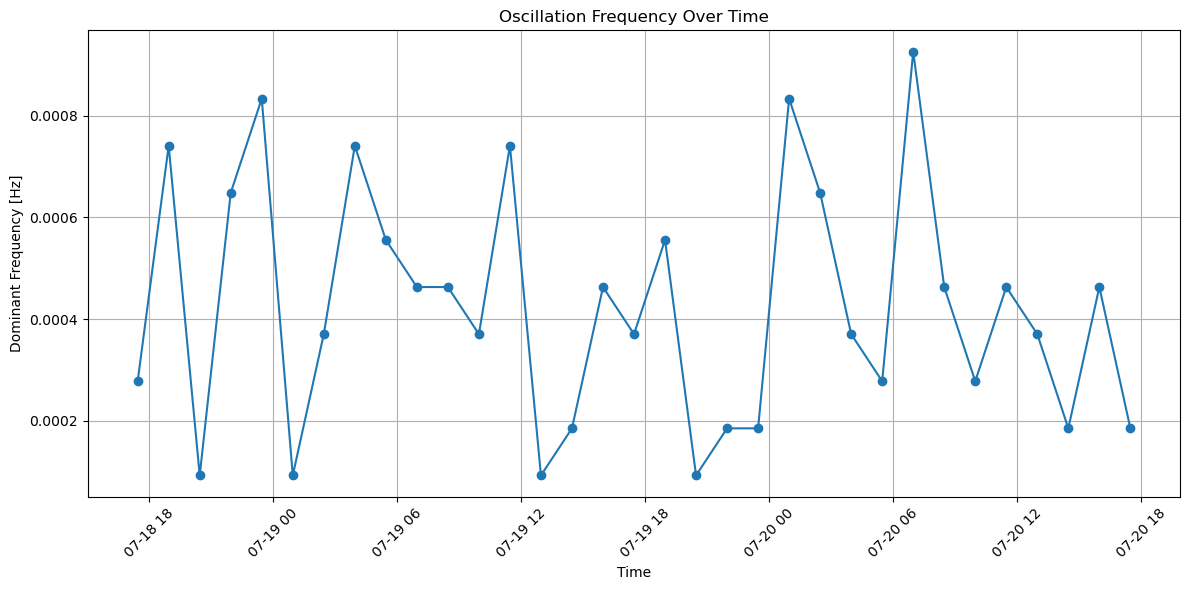

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(time_stamps, dominant_freqs, marker='o')
plt.xlabel("Time")
plt.ylabel("Dominant Frequency [Hz]")
plt.title("Oscillation Frequency Over Time")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()